# ABG Motors Market Entry Analysis

This notebook covers:
1. Model training using Japanese market data
2. Predicting Indian market potential
3. Business interpretation of model coefficients
4. Model evaluation metrics
5. Exporting prediction results for Tableau


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime


In [4]:
# Load datasets
japanese_df = pd.read_excel("JPN Data.xlsx")
indian_df = pd.read_excel("IN_Data.xlsx")

In [5]:
# Encode gender
le = LabelEncoder()
japanese_df['GENDER'] = le.fit_transform(japanese_df['GENDER'])  # M=1, F=0

# Select features and target
X_jpn = japanese_df[['CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR']]
y_jpn = japanese_df['PURCHASE']

# Scale features
scaler = StandardScaler()
X_jpn_scaled = scaler.fit_transform(X_jpn)

In [6]:
# Train logistic regression model
model = LogisticRegression()
model.fit(X_jpn_scaled, y_jpn)

LogisticRegression()

Classification Report (Japanese Data):

              precision    recall  f1-score   support

           0       0.64      0.53      0.58     16969
           1       0.69      0.78      0.73     23031

    accuracy                           0.67     40000
   macro avg       0.67      0.66      0.66     40000
weighted avg       0.67      0.67      0.67     40000



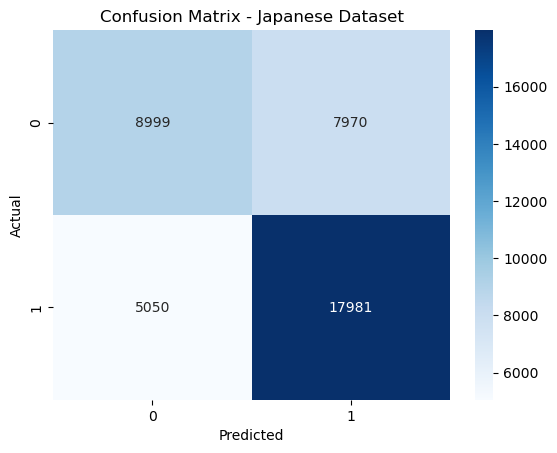

In [7]:
# Model predictions on Japanese dataset
y_pred = model.predict(X_jpn_scaled)

# Evaluation metrics
print("Classification Report (Japanese Data):\n")
print(classification_report(y_jpn, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_jpn, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Japanese Dataset")
plt.show()

## 🔍 Business Interpretation of Coefficients

Below, we examine the impact of each feature on the likelihood of car purchase:

- **Positive Coefficient** → Increases likelihood of buying
- **Negative Coefficient** → Decreases likelihood of buying


In [9]:
# Coefficients
coeff_df = pd.DataFrame({
    'Feature': ['CURR_AGE', 'GENDER (M=1)', 'ANN_INCOME', 'AGE_CAR'],
    'Coefficient': model.coef_[0]
})
print(coeff_df)

# Interpretation help
for index, row in coeff_df.iterrows():
    direction = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"- A higher {row['Feature']} {direction} the likelihood of purchasing a car.")

        Feature  Coefficient
0      CURR_AGE    -0.141549
1  GENDER (M=1)     0.112712
2    ANN_INCOME     0.418471
3       AGE_CAR     0.851503
- A higher CURR_AGE decreases the likelihood of purchasing a car.
- A higher GENDER (M=1) increases the likelihood of purchasing a car.
- A higher ANN_INCOME increases the likelihood of purchasing a car.
- A higher AGE_CAR increases the likelihood of purchasing a car.


In [10]:
# Encode and process Indian data
indian_df['GENDER'] = le.transform(indian_df['GENDER'])
indian_df['AGE_CAR'] = (pd.to_datetime('2025-01-01') - indian_df['DT_MAINT']).dt.days

X_ind = indian_df[['CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR']]
X_ind_scaled = scaler.transform(X_ind)

In [11]:
# Predict on Indian dataset
indian_df['PRED_PURCHASE'] = model.predict(X_ind_scaled)
potential_buyers = indian_df['PRED_PURCHASE'].sum()
print(f"✅ Potential Buyers in Indian Market: {potential_buyers} out of {len(indian_df)}")

✅ Potential Buyers in Indian Market: 70000 out of 70000


In [12]:
# Export for Tableau
indian_df.to_csv("Indian_Predictions.csv", index=False)
print("📁 Saved as Indian_Predictions.csv for Tableau.")

📁 Saved as Indian_Predictions.csv for Tableau.


---  
📌 **Next Step in Tableau**:
- Load `Indian_Predictions.csv` and `JPN Data.xlsx`
- Create visualizations like:
  - Bar chart: Purchase count by Gender
  - Box plot: Income vs Purchase
  - Pie chart: Purchase likelihood
  - Scatter: Age vs Income (colored by predicted purchase)

Let me know if you want a Tableau storyboard or dashboard layout!
